# Week 5 — Numerical Differentiation & Integration (Quadrature)

> **Numerical Methods from Scratch** · Pure NumPy + Matplotlib

How do we compute a derivative or an integral when we only have a function we can *evaluate*, not differentiate or integrate by hand? This week:

1. **Finite differences** for derivatives, and the **roundoff–truncation tradeoff** that makes "just take $h$ tiny" wrong.
2. **Richardson extrapolation** to cancel leading error terms and supercharge accuracy.
3. **Newton–Cotes** quadrature: midpoint, trapezoid, Simpson — and their error orders.
4. **Composite** rules and **adaptive** quadrature that spends effort where the function is hard.
5. **Gaussian quadrature**, which achieves the highest possible polynomial accuracy for a given number of points.

The Week 1 themes resurface sharply: differentiation is an *ill-conditioned* operation, while integration is *well-conditioned* — and the math explains exactly why.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Finite differences and the optimal step size

Taylor expansion gives the three classic stencils:

$$ \text{forward: } f'(x)\approx\frac{f(x+h)-f(x)}{h} = f'(x) + \mathcal{O}(h), $$
$$ \text{central: } f'(x)\approx\frac{f(x+h)-f(x-h)}{2h} = f'(x) + \mathcal{O}(h^2). $$

The **truncation error** shrinks as we reduce $h$. But each function value carries a rounding error $\sim u\,|f|$, and we divide by $h$ — so the **roundoff error grows** like $u/h$. The total error is a U-shaped curve with a sweet spot:

$$ \text{total} \approx \underbrace{C h^p}_{\text{truncation}} + \underbrace{\frac{u}{h}}_{\text{roundoff}}. $$

Making $h$ as small as possible is a classic beginner mistake. Let us *see* the U.


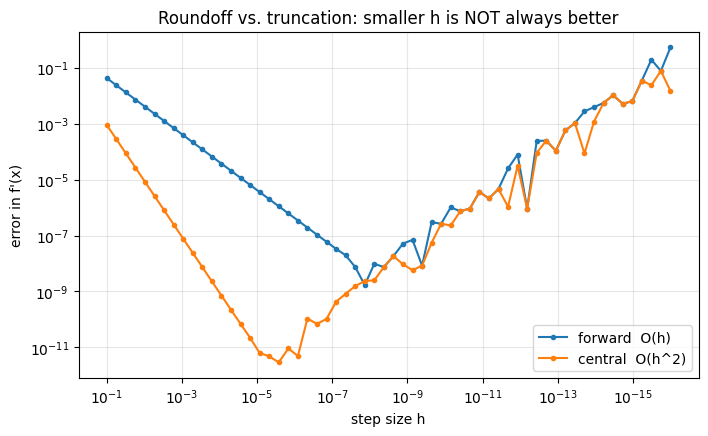

best forward h ~ 1.3664483492953271e-08  (theory ~ sqrt(u) = 1.0488088481701515e-08 )
best central h ~ 2.6529484644318946e-06  (theory ~ u^(1/3) = 4.791419857062787e-06 )


In [2]:
def forward_diff(f, x, h): return (f(x+h) - f(x)) / h
def central_diff(f, x, h): return (f(x+h) - f(x-h)) / (2*h)

f, df = np.sin, np.cos
x0 = 1.0
hs = np.logspace(-1, -16, 60)
err_fwd = np.abs(forward_diff(f, x0, hs) - df(x0))
err_cen = np.abs(central_diff(f, x0, hs) - df(x0))

fig, ax = plt.subplots()
ax.loglog(hs, err_fwd, ".-", label="forward  O(h)")
ax.loglog(hs, err_cen, ".-", label="central  O(h^2)")
ax.invert_xaxis()
ax.set_xlabel("step size h"); ax.set_ylabel("error in f'(x)")
ax.set_title("Roundoff vs. truncation: smaller h is NOT always better")
ax.legend(); plt.show()

print("best forward h ~", hs[np.argmin(err_fwd)], " (theory ~ sqrt(u) =", np.sqrt(1.1e-16), ")")
print("best central h ~", hs[np.argmin(err_cen)], " (theory ~ u^(1/3) =", (1.1e-16)**(1/3), ")")


The minima sit right where theory predicts: $h^\star \sim \sqrt{u}$ for the forward stencil and $h^\star \sim u^{1/3}$ for the central one. Past that, roundoff dominates and accuracy *degrades* as $h$ shrinks. This is the most important practical fact about numerical differentiation.

## 2. Richardson extrapolation

If a method has error $A(h) = A_0 + c\,h^p + \mathcal{O}(h^{p+1})$, we can combine two step sizes to *cancel* the leading term. For the central difference ($p=2$):

$$ A_0 \approx \frac{2^p A(h/2) - A(h)}{2^p - 1}. $$

Iterating this builds a tableau that climbs to very high order — the same idea behind **Romberg integration** later.


In [3]:
def richardson(f, x, h, p=2, levels=4):
    # Build a tableau of central-difference estimates and extrapolate.
    T = np.zeros((levels, levels))
    for i in range(levels):
        T[i, 0] = central_diff(f, x, h / 2**i)
    for j in range(1, levels):
        for i in range(j, levels):
            factor = 2.0**(p*j)
            T[i, j] = (factor * T[i, j-1] - T[i-1, j-1]) / (factor - 1)
    return T

T = richardson(np.sin, 1.0, 0.4, p=2, levels=5)
true = np.cos(1.0)
print("column 0 (plain central diff) errors:", np.abs(T[:, 0] - true))
print("diagonal (extrapolated)      errors:", np.abs(np.diag(T) - true))


column 0 (plain central diff) errors: [1.42932351e-02 3.59481820e-03 9.00053698e-04 2.25097822e-04
 5.62797314e-05]
diagonal (extrapolated)      errors: [1.42932351e-02 2.86792231e-05 6.84100088e-09 2.36921593e-13
 1.44328993e-15]


The diagonal is many orders of magnitude more accurate than the raw column — Richardson extrapolation extracts dramatically more accuracy from the *same* function evaluations.

## 3. Newton–Cotes quadrature

To approximate $\int_a^b f(x)\,dx$, replace $f$ by an interpolating polynomial and integrate that. Using equispaced nodes yields the **Newton–Cotes** family. On a single interval of width $h$:

- **Midpoint**: error $\mathcal{O}(h^3 f'')$
- **Trapezoid**: error $\mathcal{O}(h^3 f'')$
- **Simpson**: error $\mathcal{O}(h^5 f^{(4)})$ — exact for cubics!


In [4]:
def trapezoid(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return h * (0.5*y[0] + y[1:-1].sum() + 0.5*y[-1])

def simpson(f, a, b, n):
    if n % 2: n += 1                          # Simpson needs an even number of panels
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return h/3 * (y[0] + y[-1] + 4*y[1:-1:2].sum() + 2*y[2:-2:2].sum())

g = lambda x: np.exp(-x**2)
a, b = 0.0, 2.0
exact = 0.8820813907624215           # erf-based reference
print(f"trapezoid (n=100): {trapezoid(g, a, b, 100):.12f}  err {abs(trapezoid(g,a,b,100)-exact):.2e}")
print(f"simpson   (n=100): {simpson(g, a, b, 100):.12f}  err {abs(simpson(g,a,b,100)-exact):.2e}")


trapezoid (n=100): 0.882078948840  err 2.44e-06
simpson   (n=100): 0.882081390111  err 6.51e-10


### Convergence order, visualized

Halving $h$ should cut the trapezoid error by $4\times$ ($\mathcal{O}(h^2)$ globally) and the Simpson error by $16\times$ ($\mathcal{O}(h^4)$). The slope on a log–log plot reveals the order directly.


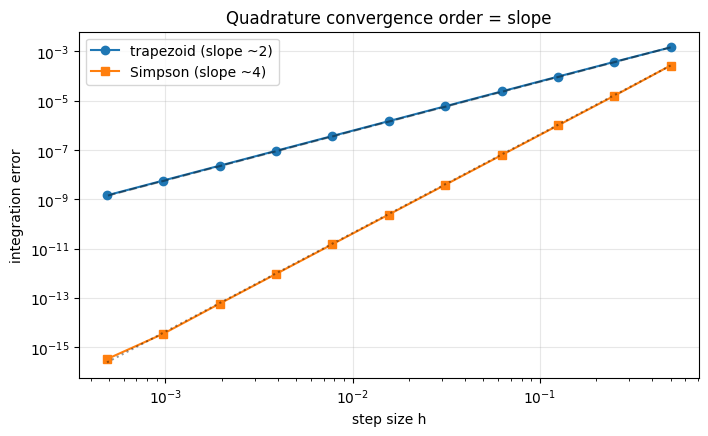

In [5]:
ns = 2 ** np.arange(2, 13)
hs = (b - a) / ns
err_trap = [abs(trapezoid(g, a, b, n) - exact) for n in ns]
err_simp = [abs(simpson(g, a, b, n) - exact) for n in ns]

fig, ax = plt.subplots()
ax.loglog(hs, err_trap, "o-", label="trapezoid (slope ~2)")
ax.loglog(hs, err_simp, "s-", label="Simpson (slope ~4)")
ax.loglog(hs, hs**2 * err_trap[0]/hs[0]**2, "k--", alpha=0.4)
ax.loglog(hs, hs**4 * err_simp[0]/hs[0]**4, "k:", alpha=0.4)
ax.set_xlabel("step size h"); ax.set_ylabel("integration error")
ax.set_title("Quadrature convergence order = slope"); ax.legend(); plt.show()


## 4. Adaptive quadrature

A fixed grid wastes effort on smooth regions and under-resolves sharp ones. **Adaptive** quadrature recursively subdivides only where a local error estimate exceeds tolerance. We compare Simpson on a whole interval against Simpson on its two halves; if they disagree by more than the tolerance, we recurse.


In [6]:
def adaptive_simpson(f, a, b, tol=1e-10, depth=50):
    def _simpson(fa, fm, fb, a, b):
        return (b - a) / 6 * (fa + 4*fm + fb)
    def _rec(a, b, fa, fm, fb, whole, tol, depth):
        m = 0.5*(a+b)
        lm, rm = 0.5*(a+m), 0.5*(m+b)
        flm, frm = f(lm), f(rm)
        left  = _simpson(fa, flm, fm, a, m)
        right = _simpson(fm, frm, fb, m, b)
        if depth <= 0 or abs(left + right - whole) <= 15*tol:
            return left + right + (left + right - whole)/15   # Richardson correction
        return (_rec(a, m, fa, flm, fm, left, tol/2, depth-1)
                + _rec(m, b, fm, frm, fb, right, tol/2, depth-1))
    fa, fb = f(a), f(b)
    m = 0.5*(a+b); fm = f(m)
    whole = _simpson(fa, fm, fb, a, b)
    return _rec(a, b, fa, fm, fb, whole, tol, depth)

# A function with a sharp spike that punishes uniform grids.
spike = lambda x: np.exp(-100*(x-0.5)**2)
val = adaptive_simpson(spike, 0, 1, tol=1e-12)
ref = np.sqrt(np.pi)/20 * (1)   # ~ approximate; compare to a very fine uniform Simpson
ref_fine = simpson(spike, 0, 1, 200000)
print(f"adaptive Simpson : {val:.12f}")
print(f"fine uniform ref : {ref_fine:.12f}")
print(f"difference       : {abs(val-ref_fine):.2e}")


adaptive Simpson : 0.177245385090
fine uniform ref : 0.177245385090
difference       : 2.14e-15


## 5. Gaussian quadrature

Newton–Cotes fixes the nodes (equispaced) and solves for weights. **Gauss–Legendre** quadrature frees *both* nodes and weights, choosing them so the rule is exact for polynomials up to degree $2n-1$ — the maximum possible with $n$ points. The optimal nodes turn out to be the roots of Legendre polynomials. We can build them from scratch by finding the eigenvalues of the **Jacobi (Golub–Welsch) matrix**.


In [7]:
def gauss_legendre(n):
    # Golub-Welsch: nodes are eigenvalues of a symmetric tridiagonal matrix.
    k = np.arange(1, n)
    beta = k / np.sqrt(4*k**2 - 1)             # off-diagonal entries
    J = np.diag(beta, 1) + np.diag(beta, -1)
    nodes, vecs = np.linalg.eigh(J)
    weights = 2 * vecs[0, :]**2                # weights from first eigenvector components
    return nodes, weights

def gauss_quad(f, a, b, n):
    x, w = gauss_legendre(n)
    # Map nodes from [-1,1] to [a,b].
    xm = 0.5*(b-a)*x + 0.5*(b+a)
    return 0.5*(b-a) * np.sum(w * f(xm))

g = lambda x: np.exp(-x**2)
print(f"{'n':>3} {'Gauss estimate':>20} {'error':>14}")
for n in [2, 4, 6, 8, 10]:
    est = gauss_quad(g, 0, 2, n)
    print(f"{n:>3} {est:>20.14f} {abs(est-exact):>14.2e}")


  n       Gauss estimate          error
  2     0.91948611664092       3.74e-02
  4     0.88222909593260       1.48e-04
  6     0.88208135535173       3.54e-08
  8     0.88208139041990       3.43e-10
 10     0.88208139076211       3.14e-13


Just **10 nodes** of Gaussian quadrature reach near machine precision — a uniform Simpson rule needs thousands of points for comparable accuracy. This is why Gauss quadrature underlies most production integrators.

## Summary

- Numerical differentiation has an **optimal step size**; smaller is not better because roundoff $\sim u/h$ eventually dominates.
- **Richardson extrapolation** cancels leading error terms for cheap accuracy gains.
- Newton–Cotes rules trade simplicity for order: trapezoid $\mathcal{O}(h^2)$, Simpson $\mathcal{O}(h^4)$.
- **Adaptive** quadrature concentrates work where the integrand is hard.
- **Gaussian quadrature** is optimal: exact to degree $2n-1$ with $n$ nodes.

---

## Exercises

**1. (Complex-step derivative.)** Implement the complex-step trick $f'(x)\approx \mathrm{Im}\,f(x+ih)/h$ and show it has **no** subtractive cancellation — accuracy keeps improving as $h\to0$, unlike finite differences. (Requires $f$ to accept complex input.)

**2. (Romberg.)** Combine the composite trapezoid rule with Richardson extrapolation to build a Romberg integration tableau. Show the diagonal converges far faster than the first column.

**3. (Second derivatives.)** Derive and implement the central stencil for $f''(x)$, find its optimal $h$ empirically, and compare to the $u^{1/4}$ scaling theory predicts.

**4. (Singular integrand.)** Integrate $\int_0^1 1/\sqrt{x}\,dx$. Explain why uniform Simpson struggles and how a substitution or adaptive refinement rescues it.

**5. (Gauss vs. Newton–Cotes.)** For a degree-7 polynomial, verify that 4-point Gauss–Legendre is *exact* while 4-point Simpson is not. Then compare both on $e^{-x^2}$ and plot error vs. number of evaluations.
